# Vision Transformer — Inference Notebook

Load a trained ViT checkpoint and run inference on CIFAR-10 test images.  
Cells are ordered so you can run them top-to-bottom with **Run All**.

## 1. Imports & Setup

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

from model import VisionTransformer

CLASSES = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
CHECKPOINT = 'checkpoints/vit_best.pth'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Using device: {DEVICE}')

Using device: cuda


## 2. Load Model

In [2]:
model = VisionTransformer(
    image_size=32,
    patch_size=4,
    hidden_dim=192,
    num_layers=12,
    num_heads=3,
    mlp_dim=768,
    num_classes=10,
    head_type='pretrain',  # must match how the model was trained
)

if os.path.exists(CHECKPOINT):
    state_dict = torch.load(CHECKPOINT, map_location=DEVICE)
    model.load_state_dict(state_dict)
    print(f'✅ Loaded checkpoint: {CHECKPOINT}')
else:
    print(f'⚠️  Checkpoint not found at "{CHECKPOINT}". Running with random weights.')

model.to(DEVICE)
model.eval()

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total_params:,}')

✅ Loaded checkpoint: checkpoints/vit_best.pth
Total trainable parameters: 5,399,818


## 3. Load Test Data

In [3]:
# Transform used at inference time (same normalization as training, no augmentation)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=16, shuffle=True, num_workers=2)

# Also keep an un-normalized copy for display
raw_testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=False,
                                            transform=transforms.ToTensor())

print(f'Test set size: {len(testset):,} images')

Test set size: 10,000 images


## 4. Run Inference & Visualize Predictions

Displays a grid of test images with their **ground truth** and **predicted** labels.  
Re-run this cell to sample a new random batch.

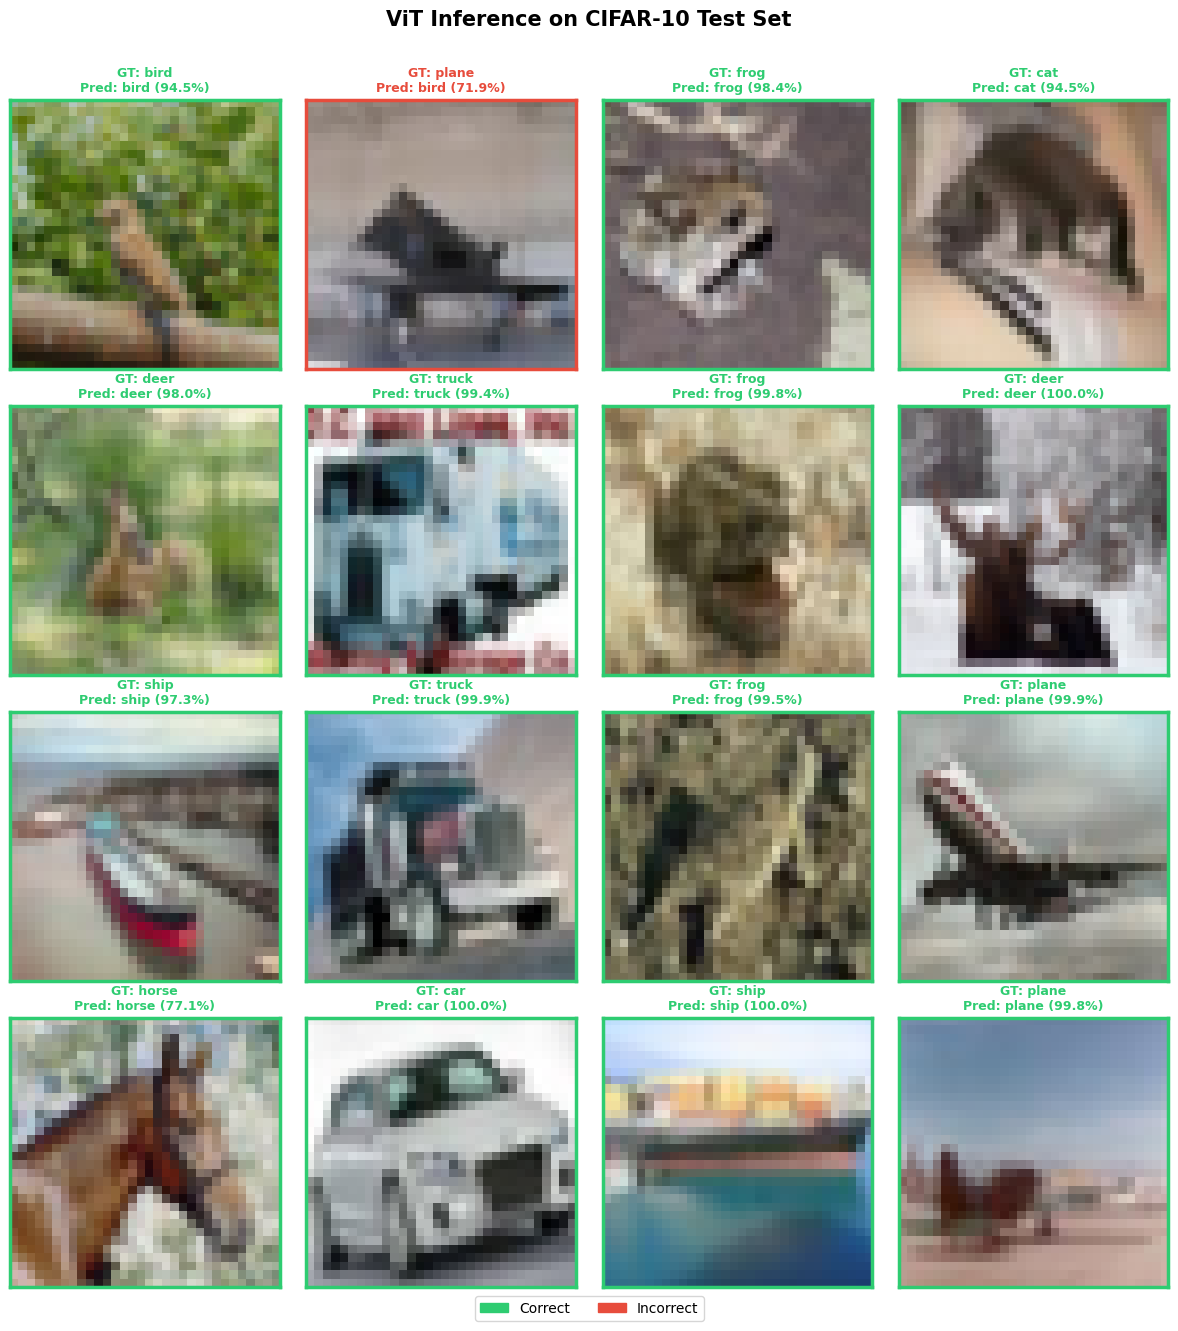

Batch accuracy: 93.8%


In [4]:
NUM_IMAGES = 16  # must be a perfect square or adjust grid below
GRID_COLS = 4
GRID_ROWS = NUM_IMAGES // GRID_COLS

# --- sample a batch ---
images_norm, labels = next(iter(testloader))
images_norm = images_norm[:NUM_IMAGES]
labels = labels[:NUM_IMAGES]

with torch.no_grad():
    logits = model(images_norm.to(DEVICE))
    probs = torch.softmax(logits, dim=-1).cpu()
    predicted = probs.argmax(dim=-1)

# --- un-normalize for display ---
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)
images_display = (images_norm * std + mean).clamp(0, 1)

# --- plot ---
fig, axes = plt.subplots(GRID_ROWS, GRID_COLS, figsize=(GRID_COLS * 3, GRID_ROWS * 3.2))
fig.suptitle('ViT Inference on CIFAR-10 Test Set', fontsize=15, fontweight='bold', y=1.01)

for i, ax in enumerate(axes.flat):
    img = images_display[i].permute(1, 2, 0).numpy()
    # Upscale 32x32 → display nicer
    ax.imshow(img, interpolation='nearest')

    gt   = CLASSES[labels[i]]
    pred = CLASSES[predicted[i]]
    conf = probs[i][predicted[i]].item() * 100
    correct = (labels[i] == predicted[i]).item()

    color = '#2ecc71' if correct else '#e74c3c'   # green / red
    ax.set_title(
        f'GT: {gt}\nPred: {pred} ({conf:.1f}%)',
        fontsize=9, color=color, fontweight='bold'
    )
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2.5)
    ax.set_xticks([])
    ax.set_yticks([])

correct_patch = mpatches.Patch(color='#2ecc71', label='Correct')
wrong_patch   = mpatches.Patch(color='#e74c3c', label='Incorrect')
fig.legend(handles=[correct_patch, wrong_patch], loc='lower center',
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.show()

batch_acc = (predicted == labels).float().mean().item() * 100
print(f'Batch accuracy: {batch_acc:.1f}%')

## 5. Confidence Bar Chart for a Single Image

Pick any index from the batch above to see the full probability distribution.

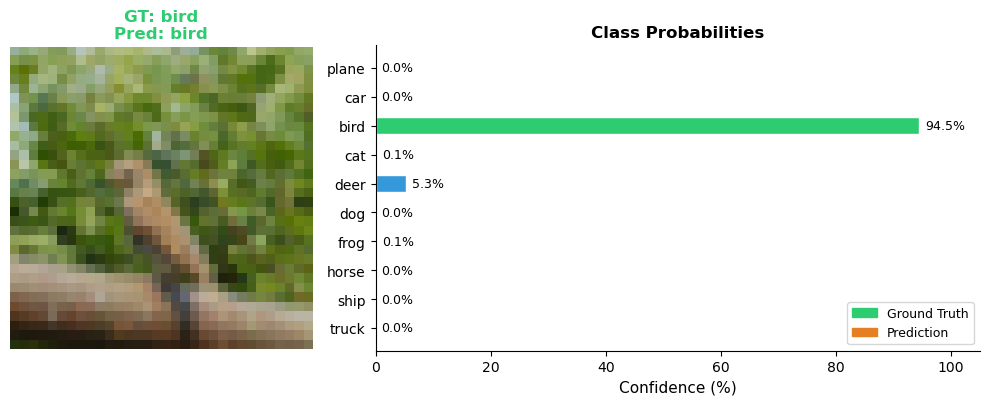

In [5]:
IDX = 0  # ← change this to inspect a different image from the batch

img_display = images_display[IDX].permute(1, 2, 0).numpy()
class_probs = probs[IDX].numpy() * 100
gt_label    = CLASSES[labels[IDX]]
pred_label  = CLASSES[predicted[IDX]]

fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(10, 4),
                                      gridspec_kw={'width_ratios': [1, 2]})

# --- image panel ---
ax_img.imshow(img_display, interpolation='nearest')
ax_img.set_title(f'GT: {gt_label}\nPred: {pred_label}', fontsize=12, fontweight='bold',
                 color='#2ecc71' if gt_label == pred_label else '#e74c3c')
ax_img.axis('off')

# --- bar chart panel ---
bar_colors = ['#3498db'] * 10
bar_colors[list(CLASSES).index(gt_label)]   = '#2ecc71'  # ground truth → green
bar_colors[list(CLASSES).index(pred_label)] = '#e67e22'  # prediction → orange
# If they match, green wins
if gt_label == pred_label:
    bar_colors[list(CLASSES).index(gt_label)] = '#2ecc71'

bars = ax_bar.barh(CLASSES, class_probs, color=bar_colors, edgecolor='white', height=0.6)
ax_bar.set_xlabel('Confidence (%)', fontsize=11)
ax_bar.set_title('Class Probabilities', fontsize=12, fontweight='bold')
ax_bar.set_xlim(0, 105)
ax_bar.invert_yaxis()
ax_bar.spines[['top', 'right']].set_visible(False)

for bar, val in zip(bars, class_probs):
    ax_bar.text(val + 1, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', fontsize=9)

# legend
gt_patch   = mpatches.Patch(color='#2ecc71', label='Ground Truth')
pred_patch = mpatches.Patch(color='#e67e22', label='Prediction')
ax_bar.legend(handles=[gt_patch, pred_patch], loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Patch Grid Visualization

Shows how the ViT sees the image: each 4×4 patch that gets independently embedded.

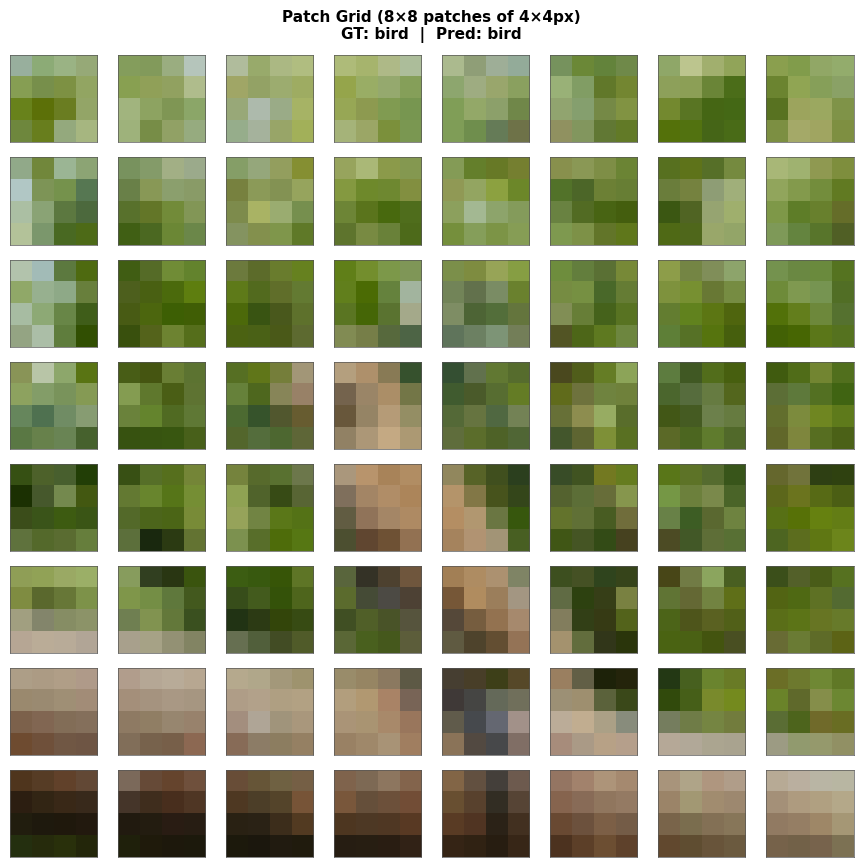

Total patches fed to the Transformer (excl. CLS token): 64


In [6]:
IDX = 0          # ← image index from the batch
PATCH_SIZE = 4   # must match the model

img = images_display[IDX].permute(1, 2, 0).numpy()  # (32, 32, 3)
H, W, _ = img.shape
num_patches_h = H // PATCH_SIZE
num_patches_w = W // PATCH_SIZE

fig, axes = plt.subplots(num_patches_h, num_patches_w,
                          figsize=(num_patches_w * 1.1, num_patches_h * 1.1))
fig.suptitle(
    f'Patch Grid ({num_patches_h}×{num_patches_w} patches of {PATCH_SIZE}×{PATCH_SIZE}px)\n'
    f'GT: {CLASSES[labels[IDX]]}  |  Pred: {CLASSES[predicted[IDX]]}',
    fontsize=11, fontweight='bold'
)

for row in range(num_patches_h):
    for col in range(num_patches_w):
        patch = img[row*PATCH_SIZE:(row+1)*PATCH_SIZE,
                    col*PATCH_SIZE:(col+1)*PATCH_SIZE]
        ax = axes[row][col]
        ax.imshow(patch, interpolation='nearest')
        ax.set_xticks([])
        ax.set_yticks([])
        # subtle border
        for spine in ax.spines.values():
            spine.set_edgecolor('#555')
            spine.set_linewidth(0.5)

plt.tight_layout()
plt.show()

print(f'Total patches fed to the Transformer (excl. CLS token): {num_patches_h * num_patches_w}')

## 7. Overall Test Set Accuracy


Overall test accuracy: 84.35%



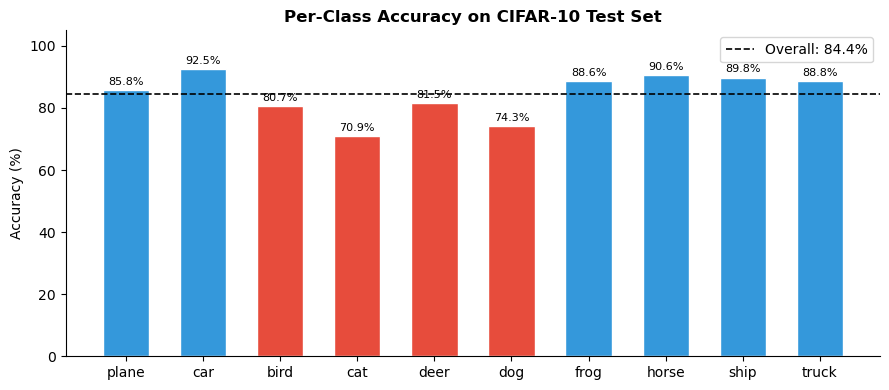

In [7]:
full_loader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=2)

all_correct = 0
all_total   = 0
class_correct = [0] * 10
class_total   = [0] * 10

model.eval()
with torch.no_grad():
    for imgs, lbls in full_loader:
        logits = model(imgs.to(DEVICE))
        preds  = logits.argmax(dim=-1).cpu()
        all_correct += (preds == lbls).sum().item()
        all_total   += lbls.size(0)
        for c in range(10):
            mask = (lbls == c)
            class_correct[c] += (preds[mask] == lbls[mask]).sum().item()
            class_total[c]   += mask.sum().item()

overall_acc = all_correct / all_total * 100
print(f'\nOverall test accuracy: {overall_acc:.2f}%\n')

# Per-class breakdown
per_class_acc = [class_correct[i] / class_total[i] * 100 for i in range(10)]
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#3498db' if a >= overall_acc else '#e74c3c' for a in per_class_acc]
bars = ax.bar(CLASSES, per_class_acc, color=colors, edgecolor='white', width=0.6)
ax.axhline(overall_acc, color='black', linestyle='--', linewidth=1.2, label=f'Overall: {overall_acc:.1f}%')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Accuracy on CIFAR-10 Test Set', fontweight='bold')
ax.set_ylim(0, 105)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=10)
for bar, val in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}%',
            ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()